Matrice de confusion pour les 5 sujets

Importation des librairies et des données

In [19]:
import os
import nibabel as nib
import pandas as pd
import numpy as np
from nilearn.maskers import NiftiLabelsMasker
from nilearn import datasets
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Configuration
base_path_template = "/home/etudiants/psy3019/travail_final/ds003720"
subjects = ['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005']
t_r = 2.0

# Atlas Schaefer 100
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, resolution_mm=2)
masker = NiftiLabelsMasker(labels_img=atlas.maps, standardize=True, t_r=t_r)

# Collecte TOUS les trials
all_X = []
all_y = []
task_stats = {'Test': {}, 'Training': {}}

for subject in subjects:
    for task in ['Test', 'Training']:
        base_path = f"{base_path_template}/{subject}/func"
        n_runs = 6 if task == 'Test' else 12
        
        subject_X = []
        subject_y = []
        
        for run in tqdm(range(1, n_runs + 1), desc=f"{subject}-{task}"):
            run_str = f"run-0{run}"
            bold_file = f"{base_path}/{subject}_task-{task}_{run_str}_bold.nii"
            events_file = f"{base_path}/{subject}_task-{task}_{run_str}_events.tsv"
            
            if not (os.path.exists(bold_file) and os.path.exists(events_file)):
                continue
                
            # Load
            func_img = nib.load(bold_file)
            events = pd.read_csv(events_file, sep="\t")
            
            roi_ts = masker.fit_transform(func_img)  # [timepoints, 100]
            
            # Trials
            for _, row in events.iterrows():
                onset, duration, genre = row['onset'], row['duration'], row['genre']
                start_vol = int(onset / t_r)
                end_vol = int((onset + duration) / t_r)
                trial_ts = roi_ts[start_vol:end_vol, :]
                
                if trial_ts.shape[0] < 2: continue
                
                conn = np.corrcoef(trial_ts.T)
                flat = conn[np.triu_indices_from(conn, k=1)]
                
                if len(flat) == 4950 and not np.isnan(flat).any():
                    subject_X.append(flat)
                    subject_y.append(genre)
        
        print(f"{subject}-{task}: {len(subject_X)} trials")
        all_X.extend(subject_X)
        all_y.extend(subject_y)
        
        task_stats[task][subject] = len(subject_X)

# Entraînement
X = np.array(all_X)
y = np.array(all_y)
print(f"\nTotal: {X.shape[0]} trials, {len(np.unique(y))} genres")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))

[fetch_atlas_schaefer_2018] Dataset found in /home/etudiants/nilearn_data/schaefer_2018

sub-001-Test:   0%|                                                                   | 0/6 [00:00<?, ?it/s]/tmp/ipykernel_6202/1925989525.py:46: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.float32(4.0), np.float32(54.0)}. Label image only contains 99 labels (including background).
  roi_ts = masker.fit_transform(func_img)  # [timepoints, 100]
/tmp/ipykernel_6202/1925989525.py:46: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  roi_ts = masker.fit_transform(func_img)  # [timepoints, 100]
sub-001-Test:  17%|█████████▊                                                 | 1/6 [00:17<01:29, 17.87s/it]/tmp/ipykernel_6202/1925989525.

sub-001-Test: 82 trials


sub-001-Training:   0%|                                                              | 0/12 [00:00<?, ?it/s]/tmp/ipykernel_6202/1925989525.py:46: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.float32(4.0), np.float32(54.0)}. Label image only contains 99 labels (including background).
  roi_ts = masker.fit_transform(func_img)  # [timepoints, 100]
/tmp/ipykernel_6202/1925989525.py:46: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  roi_ts = masker.fit_transform(func_img)  # [timepoints, 100]
sub-001-Training:   8%|████▌                                                 | 1/12 [00:17<03:17, 17.98s/it]/tmp/ipykernel_6202/1925989525.

sub-001-Training: 41 trials


...

sub-005-Test:   0%|                                                                   | 0/6 [00:00<?, ?it/s]/tmp/ipykernel_6202/1925989525.py:46: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  roi_ts = masker.fit_transform(func_img)  # [timepoints, 100]
sub-005-Test:  17%|█████████▊                                                 | 1/6 [00:17<01:28, 17.62s/it]/tmp/ipykernel_6202/1925989525.py:46: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_samp

sub-005-Test: 164 trials


sub-005-Training:   0%|                                                              | 0/12 [00:00<?, ?it/s]/tmp/ipykernel_6202/1925989525.py:46: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  roi_ts = masker.fit_transform(func_img)  # [timepoints, 100]
sub-005-Training:   8%|████▌                                                 | 1/12 [00:18<03:20, 18.25s/it]/tmp/ipykernel_6202/1925989525.py:46: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_samp

sub-005-Training: 205 trials

Total: 1722 trials, 13 genres
Accuracy: 0.064
              precision    recall  f1-score   support

     'blues'       0.07      0.12      0.09        34
 'classical'       0.05      0.06      0.05        33
   'country'       0.07      0.06      0.06        34
     'disco'       0.07      0.06      0.06        34
    'hiphop'       0.10      0.09      0.09        34
      'jazz'       0.15      0.15      0.15        34
     'metal'       0.00      0.00      0.00        35
       'pop'       0.03      0.03      0.03        35
    'reggae'       0.03      0.03      0.03        36
      'rock'       0.05      0.06      0.05        34
  classical'       0.00      0.00      0.00         1
      metal'       0.00      0.00      0.00         1

    accuracy                           0.06       345
   macro avg       0.05      0.05      0.05       345
weighted avg       0.06      0.06      0.06       345



/home/etudiants/miniconda3/envs/manipulation_neuroimagerie/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/etudiants/miniconda3/envs/manipulation_neuroimagerie/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/etudiants/miniconda3/envs/manipulation_neuroimagerie/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

Classes: [np.str_("'blues'"), np.str_("'classical'"), np.str_("'country'"), np.str_("'disco'"), np.str_("'hiphop'"), np.str_("'jazz'"), np.str_("'metal'"), np.str_("'pop'"), np.str_("'reggae'"), np.str_("'rock'"), np.str_("classical'"), np.str_("metal'")]
CM shape: (12, 12)


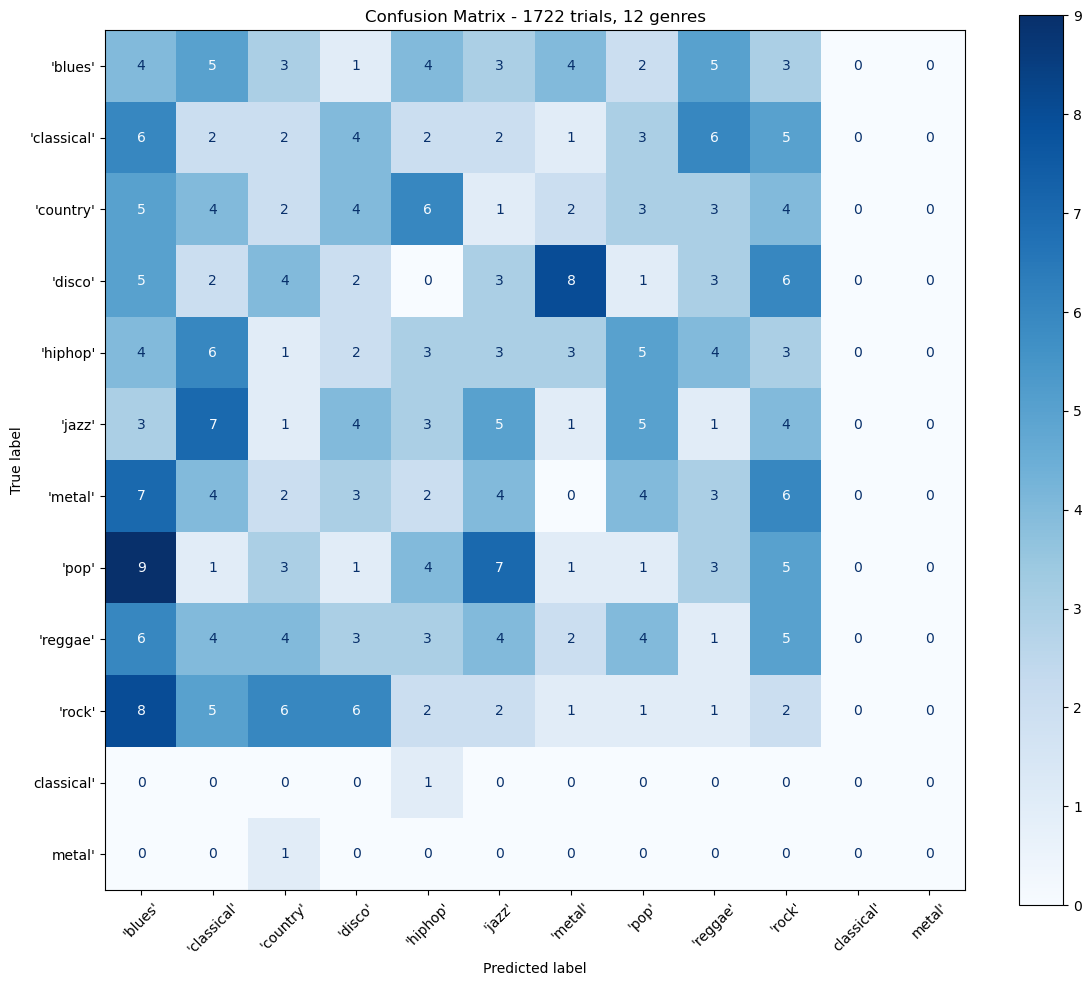


Matrice sauvée: confusion_matrix_final.png
Stats sauvées: results_summary.csv


In [21]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# CORRECTION: Utiliser les vraies classes du test set seulement
labels = sorted(np.unique(np.concatenate([y_test, y_pred])))  # Classes présentes dans test+pred

cm = confusion_matrix(y_test, y_pred, labels=labels)
print(f"Classes: {labels}")
print(f"CM shape: {cm.shape}")

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix - {X.shape[0]} trials, {len(labels)} genres")
plt.tight_layout()
plt.savefig("confusion_matrix_final.png", dpi=300, bbox_inches='tight')
plt.show()

# Stats en CSV
results_df = pd.DataFrame({
    'metric': ['accuracy', 'n_trials', 'n_genres', 'n_subjects'],
    'value': [accuracy_score(y_test, y_pred), len(y_test), len(labels), len(subjects)]
})
results_df.to_csv("results_summary.csv", index=False)
print("\nMatrice sauvée: confusion_matrix_final.png")
print("Stats sauvées: results_summary.csv")